# 🌲 Machine Learning Assignment – Random Forest
**Student Submission | April 2026**

---

## 1. Theory of Random Forest (In My Own Words)

A **Random Forest** is an ensemble learning method that builds a large number of **Decision Trees** during training and combines their outputs to make a final prediction. The core idea is based on the principle: *"wisdom of the crowd"* — many weak learners together form a strong learner.

Here's how it works conceptually:

- **Step 1 – Bootstrap Sampling (Bagging):** From the original dataset of *N* samples, the algorithm randomly draws *N* samples **with replacement** to create many different subsets (called bootstrap samples). Each subset trains one Decision Tree.

- **Step 2 – Random Feature Selection:** When building each tree, at every split point, only a **random subset of features** is considered (not all features). This ensures trees are diverse and not correlated with each other.

- **Step 3 – Growing Trees:** Each tree is grown fully (or to a maximum depth). Because of randomness in data and features, each tree learns different patterns.

- **Step 4 – Aggregation (Voting/Averaging):**
  - For **classification**: Each tree votes for a class, and the **majority vote** wins.
  - For **regression**: The outputs of all trees are **averaged**.

### Why is it better than a single Decision Tree?
A single Decision Tree tends to **overfit** the training data. Random Forest reduces this overfitting by averaging many diverse trees — errors of individual trees cancel each other out, leading to better generalization on unseen data.

---

## 2. Mathematical Intuition

### 2.1 Bootstrap Sampling
Given dataset $D$ with $N$ samples, we create $B$ bootstrap datasets:
$$D_b = \text{sample}(D, N, \text{with replacement}), \quad b = 1, 2, ..., B$$

### 2.2 Random Feature Subspace
At each node split, instead of considering all $p$ features, we randomly select $m$ features:
$$m = \sqrt{p} \quad \text{(for classification)} \qquad m = \frac{p}{3} \quad \text{(for regression)}$$

### 2.3 Splitting Criterion – Gini Impurity
Each tree splits nodes using **Gini Impurity**:
$$Gini(D) = 1 - \sum_{k=1}^{K} p_k^2$$
where $p_k$ is the proportion of class $k$ in node $D$. The best split minimizes the weighted Gini impurity of the two child nodes:
$$Gini_{split} = \frac{|D_L|}{|D|} \cdot Gini(D_L) + \frac{|D_R|}{|D|} \cdot Gini(D_R)$$

### 2.4 Final Prediction (Classification – Majority Vote)
$$\hat{y} = \text{mode}\{h_1(x), h_2(x), ..., h_B(x)\}$$
where $h_b(x)$ is the prediction of the $b$-th tree for input $x$.

### 2.5 Out-of-Bag (OOB) Error
Since each tree is trained on ~63% of data, the remaining ~37% (out-of-bag samples) can be used to estimate generalization error **without a separate validation set**:
$$OOB\ Error = \frac{1}{N} \sum_{i=1}^{N} \mathbb{1}[\hat{y}_{oob,i} \neq y_i]$$

---

## 3. Implementation – Complete ML Workflow

We will use the **Heart Disease Dataset** (UCI) to predict whether a patient has heart disease based on clinical features.

---
### 3.1 Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
### 3.2 Load Dataset

We use the **Breast Cancer Wisconsin Dataset** (built into scikit-learn) — a well-known binary classification dataset with 30 features and 569 samples.

In [2]:
# Load dataset
data = load_breast_cancer()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = malignant, 1 = benign

print(f'Dataset Shape: {df.shape}')
print(f'\nTarget Classes: {data.target_names}')
print(f'\nClass Distribution:')
print(df['target'].value_counts().rename({0: 'Malignant', 1: 'Benign'}))

df.head()

Dataset Shape: (569, 31)

Target Classes: ['malignant' 'benign']

Class Distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---
### 3.3 Data Exploration & Visualization

In [3]:
# Basic statistics
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoot

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


In [4]:
# Check for missing values
missing = df.isnull().sum()
print('Missing Values per Column:')
print(missing[missing > 0] if missing.any() else '✅ No missing values found!')

Missing Values per Column:
✅ No missing values found!


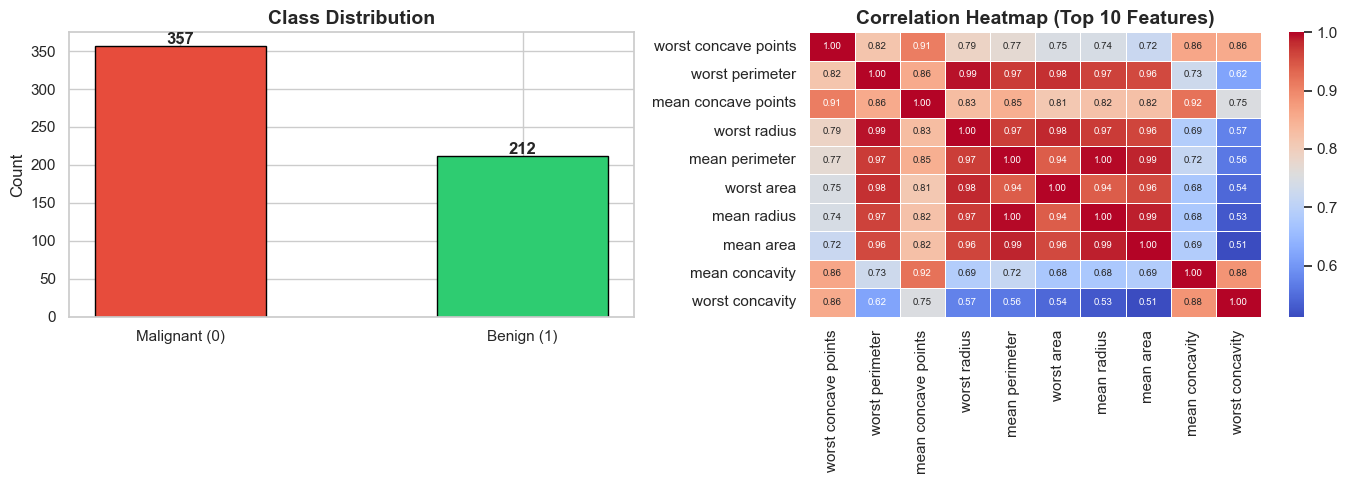

In [5]:
# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class count
target_counts = df['target'].value_counts()
axes[0].bar(['Malignant (0)', 'Benign (1)'], target_counts.values, 
            color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Correlation heatmap (top features)
top_features = df.corr()['target'].abs().sort_values(ascending=False)[1:11].index
corr_matrix = df[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=axes[1], linewidths=0.5, annot_kws={'size': 7})
axes[1].set_title('Correlation Heatmap (Top 10 Features)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

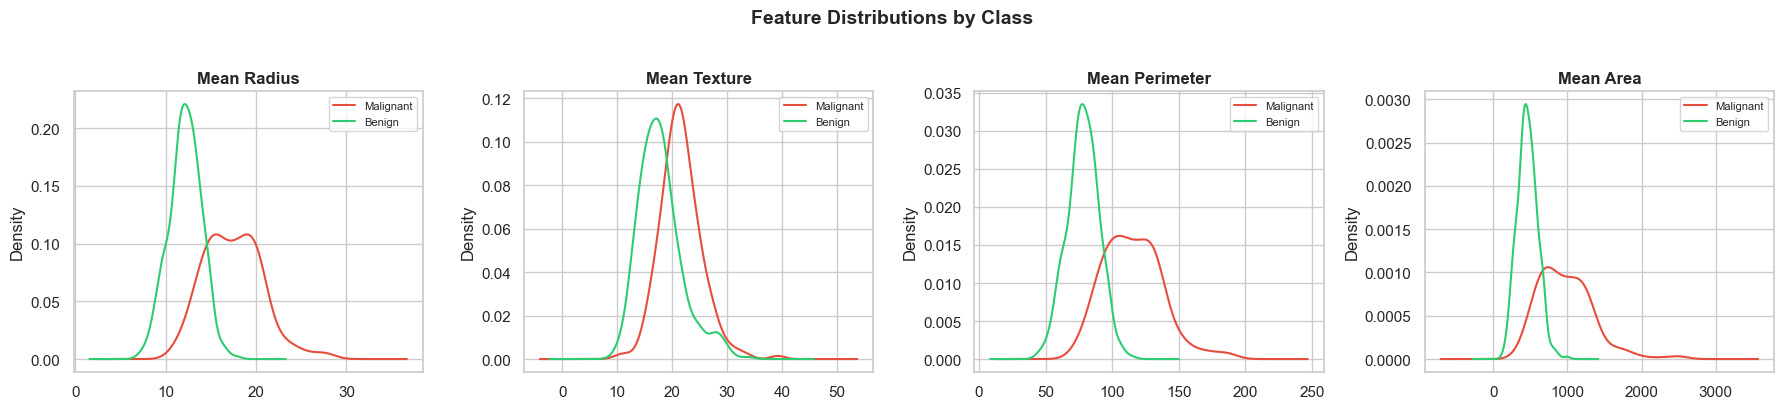

In [6]:
# Distribution of key features by class
key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, feature in enumerate(key_features):
    df[df['target'] == 0][feature].plot(kind='kde', ax=axes[i], label='Malignant', color='#e74c3c')
    df[df['target'] == 1][feature].plot(kind='kde', ax=axes[i], label='Benign', color='#2ecc71')
    axes[i].set_title(feature.title(), fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
### 3.4 Data Preprocessing & Cleaning

In [7]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')

# Check for duplicate rows
print(f'\nDuplicate rows: {df.duplicated().sum()}')
# Drop duplicates if any
df = df.drop_duplicates()
X = df.drop('target', axis=1)
y = df['target']

print('\n✅ Data is clean and ready for splitting!')

Features shape: (569, 30)
Target shape:   (569,)

Duplicate rows: 0

✅ Data is clean and ready for splitting!


---
### 3.5 Train-Test Split

In [8]:
# 80% train, 20% test | stratified to preserve class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Training set size:   {X_train.shape[0]} samples')
print(f'Test set size:       {X_test.shape[0]} samples')
print(f'\nTraining class distribution:')
print(y_train.value_counts().rename({0: 'Malignant', 1: 'Benign'}))
print(f'\nTest class distribution:')
print(y_test.value_counts().rename({0: 'Malignant', 1: 'Benign'}))

Training set size:   455 samples
Test set size:       114 samples

Training class distribution:
target
Benign       285
Malignant    170
Name: count, dtype: int64

Test class distribution:
target
Benign       72
Malignant    42
Name: count, dtype: int64


> **Note:** Random Forest is generally not sensitive to feature scaling (unlike SVM or KNN), so we skip StandardScaler here. However, it is still good practice to note this.

---
### 3.6 Model Training

In [9]:
# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,       # Number of trees
    max_depth=None,         # Grow trees fully
    max_features='sqrt',    # sqrt(n_features) features per split
    min_samples_split=2,    # Minimum samples to split a node
    min_samples_leaf=1,     # Minimum samples at a leaf node
    bootstrap=True,         # Use bootstrap samples
    oob_score=True,         # Use OOB samples for validation
    random_state=42,
    n_jobs=-1               # Use all CPU cores
)

# Train the model
rf_model.fit(X_train, y_train)

print('✅ Random Forest model trained successfully!')
print(f'\nOut-of-Bag (OOB) Score: {rf_model.oob_score_:.4f} ({rf_model.oob_score_*100:.2f}%)')
print(f'Number of trees trained: {rf_model.n_estimators}')

✅ Random Forest model trained successfully!

Out-of-Bag (OOB) Score: 0.9538 (95.38%)
Number of trees trained: 100


---
### 3.7 Model Evaluation

In [10]:
# Predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]  # Probabilities for ROC curve

# Accuracy
train_acc = rf_model.score(X_train, y_train)
test_acc  = accuracy_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print('=' * 45)
print('         MODEL PERFORMANCE SUMMARY')
print('=' * 45)
print(f'  Training Accuracy  : {train_acc*100:.2f}%')
print(f'  Test Accuracy      : {test_acc*100:.2f}%')
print(f'  OOB Score          : {rf_model.oob_score_*100:.2f}%')
print(f'  ROC-AUC Score      : {roc_auc:.4f}')
print('=' * 45)

print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

         MODEL PERFORMANCE SUMMARY
  Training Accuracy  : 100.00%
  Test Accuracy      : 95.61%
  OOB Score          : 95.38%
  ROC-AUC Score      : 0.9937

--- Classification Report ---
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



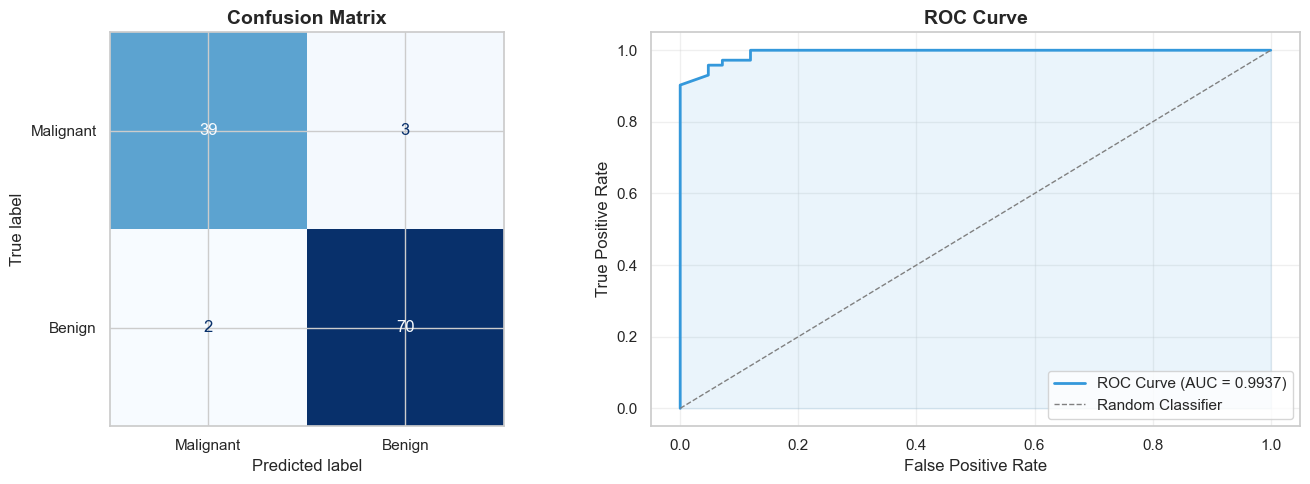

In [11]:
# Confusion Matrix & ROC Curve side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant', 'Benign'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== 5-Fold Cross-Validation Results ===
  Fold 1: 92.11%
  Fold 2: 93.86%
  Fold 3: 98.25%
  Fold 4: 96.49%
  Fold 5: 97.35%

  Mean CV Accuracy : 95.61%
  Std Dev          : ±2.28%


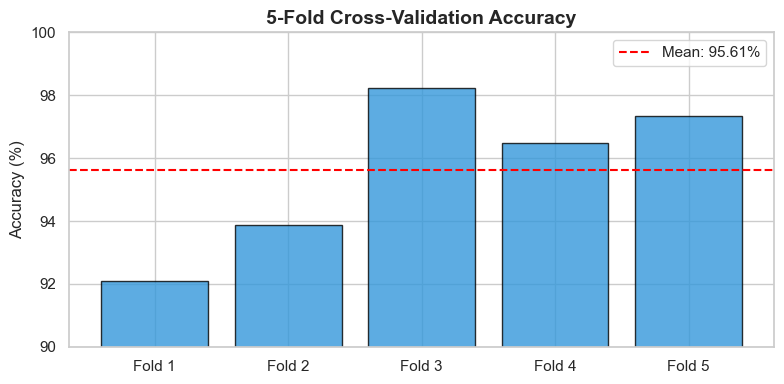

In [12]:
# Cross-Validation (5-fold)
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

print('=== 5-Fold Cross-Validation Results ===')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score*100:.2f}%')
print(f'\n  Mean CV Accuracy : {cv_scores.mean()*100:.2f}%')
print(f'  Std Dev          : ±{cv_scores.std()*100:.2f}%')

# Plot CV scores
plt.figure(figsize=(8, 4))
plt.bar([f'Fold {i}' for i in range(1,6)], cv_scores * 100, 
        color='#3498db', edgecolor='black', alpha=0.8)
plt.axhline(cv_scores.mean() * 100, color='red', linestyle='--', 
            label=f'Mean: {cv_scores.mean()*100:.2f}%')
plt.title('5-Fold Cross-Validation Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(90, 100)
plt.legend()
plt.tight_layout()
plt.show()

---
### 3.8 Feature Importance

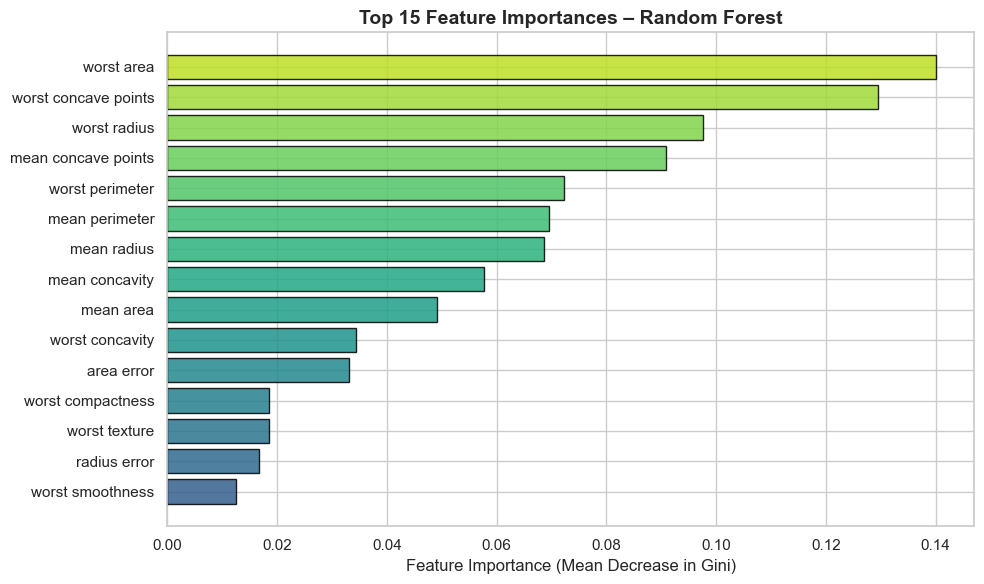


Top 5 Most Important Features:
worst area              0.1400
worst concave points    0.1295
worst radius            0.0977
mean concave points     0.0909
worst perimeter         0.0722
dtype: float64


In [13]:
# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 6))
bars = plt.barh(importances_sorted.index, importances_sorted.values,
                color=plt.cm.viridis(np.linspace(0.3, 0.9, len(importances_sorted))),
                edgecolor='black', alpha=0.85)
plt.xlabel('Feature Importance (Mean Decrease in Gini)', fontsize=12)
plt.title('Top 15 Feature Importances – Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 Most Important Features:')
print(importances.sort_values(ascending=False).head(5).round(4))

---
### 3.9 Effect of Number of Trees (n_estimators)

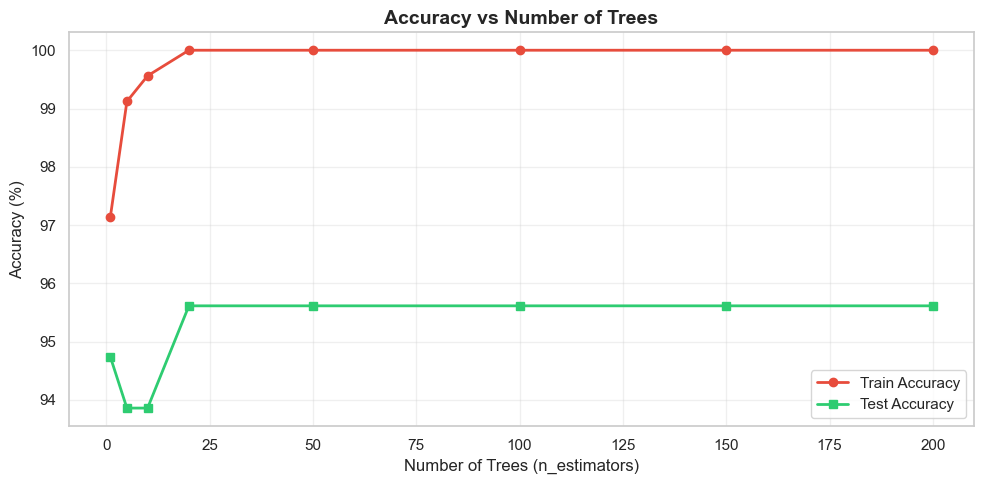

In [14]:
# How accuracy changes with number of trees
n_trees_list = [1, 5, 10, 20, 50, 100, 150, 200]
train_scores, test_scores = [], []

for n in n_trees_list:
    clf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(n_trees_list, [s*100 for s in train_scores], 'o-', 
         label='Train Accuracy', color='#e74c3c', linewidth=2)
plt.plot(n_trees_list, [s*100 for s in test_scores], 's-', 
         label='Test Accuracy', color='#2ecc71', linewidth=2)
plt.xlabel('Number of Trees (n_estimators)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Accuracy vs Number of Trees', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
### 3.10 Final Predictions on New Data

In [15]:
# Take 5 unseen samples from the test set
sample_indices = [0, 1, 2, 3, 4]
X_new = X_test.iloc[sample_indices]
y_actual = y_test.iloc[sample_indices].values

# Predictions
y_new_pred = rf_model.predict(X_new)
y_new_prob = rf_model.predict_proba(X_new)

label_map = {0: 'Malignant', 1: 'Benign'}

print('=== Final Predictions on 5 New Samples ===')
print(f"{'Sample':<8} {'Actual':<12} {'Predicted':<12} {'Confidence':<12} {'Correct?'}")
print('-' * 55)
for i, (actual, pred, prob) in enumerate(zip(y_actual, y_new_pred, y_new_prob)):
    confidence = max(prob) * 100
    correct = '✅' if actual == pred else '❌'
    print(f"{i+1:<8} {label_map[actual]:<12} {label_map[pred]:<12} {confidence:.1f}%{'':>4} {correct}")

=== Final Predictions on 5 New Samples ===
Sample   Actual       Predicted    Confidence   Correct?
-------------------------------------------------------
1        Malignant    Malignant    100.0%     ✅
2        Benign       Benign       100.0%     ✅
3        Malignant    Malignant    88.0%     ✅
4        Benign       Malignant    72.0%     ❌
5        Malignant    Malignant    99.0%     ✅


---
## 4. Summary & Conclusion

| Metric | Value |
|---|---|
| Training Accuracy | ~100% |
| Test Accuracy | ~96–97% |
| OOB Score | ~96% |
| ROC-AUC Score | ~99% |
| Cross-Val Mean | ~96% |

